# EDA Who pays

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [77]:
# Daten laden
okp = pd.read_csv('../data/whopays/processed_whopays/okp_by_birth_year.csv')
ahv_ein = pd.read_csv('../data/whopays/processed_whopays/ahv_einnahmen_by_birth_year.csv')
ahv_aus = pd.read_csv('../data/whopays/processed_whopays/ahv_ausgaben_by_age.csv')

# Erste Übersicht
for name, df in [('OKP', okp), ('AHV Einnahmen', ahv_ein), ('AHV Ausgaben', ahv_aus)]:
    print(f'=== {name} ===')
    print(f'Shape: {df.shape}')
    print(f'Spalten: {list(df.columns)}')
    print()

=== OKP ===
Shape: (18403, 15)
Spalten: ['year', 'variable_name', 'age_group_label', 'age_min', 'age_max', 'metric', 'value', 'unit', 'scale', 'notes', 'age', 'birth_year', 'project_age_group', 'project_age_order', 'method']

=== AHV Einnahmen ===
Shape: (4545, 15)
Spalten: ['year', 'variable_name', 'age_group_label', 'age_min', 'age_max', 'metric', 'value', 'unit', 'scale', 'notes', 'age', 'birth_year', 'project_age_group', 'project_age_order', 'method']

=== AHV Ausgaben ===
Shape: (1404, 11)
Spalten: ['year', 'variable_name', 'age', 'birth_year', 'project_age_group', 'project_age_order', 'metric', 'value', 'unit', 'scale', 'notes']



In [78]:
# Verhaeltnis: Einzahlende vs. Bezüger
einzahlende = ahv_ein[
    ahv_ein['metric'] == 'n_personen'
].groupby('year')['value'].sum().reset_index()
einzahlende.columns = ['year', 'n_einzahlende']

bezueger = ahv_aus[
    ahv_aus['metric'] == 'anzahl_renten'
].groupby('year')['value'].sum().reset_index()
bezueger.columns = ['year', 'n_bezueger']

verhaeltnis = einzahlende.merge(bezueger, on='year')
verhaeltnis['ratio'] = verhaeltnis['n_einzahlende'] / verhaeltnis['n_bezueger']

In [79]:
# Was sind die eindeutigen Werte in den wichtigsten Kategoriespalten?
print('=== OKP Metriken ===')
print(okp['metric'].unique())
print(okp['variable_name'].unique())

print('\n=== AHV Einnahmen Metriken ===')
print(ahv_ein['metric'].unique())

print('\n=== AHV Ausgaben Metriken ===')
print(ahv_aus['metric'].unique())

print('\n=== Generationen (OKP) ===')
print(okp[['project_age_group', 'project_age_order']].drop_duplicates().sort_values('project_age_order').to_string(index=False))

=== OKP Metriken ===
['beneficiaries_count' 'beneficiary_rate' 'total_mio_chf' 'per_capita_chf']
['praemienverbilligung' 'okp_kostenbeteiligung' 'okp_nettoleistungen'
 'okp_bruttoleistungen' 'okp_premium']

=== AHV Einnahmen Metriken ===
['n_personen' 'sum_einkommen' 'sum_beitrag_ahv']

=== AHV Ausgaben Metriken ===
['anzahl_renten' 'rentensumme_tausend_chf' 'renten_mittelwert_chf']

=== Generationen (OKP) ===
project_age_group  project_age_order
Silent Generation                  1
      Babyboomers                  2
     Generation X                  3
      Millennials                  4
     Generation Z                  5
 Generation Alpha                  6


In [80]:
# Geburtsjahre in der OKP-Datei prüfen
print('Geburtsjahr-Bereich pro Generation:')
print(okp.groupby('project_age_group')['birth_year'].agg(['min', 'max', 'count']))
print()
print('Sind Geburtsjahre 1997-2012 vorhanden?')
print(okp[(okp['birth_year'] >= 1997) & (okp['birth_year'] <= 2012)]['birth_year'].unique())

Geburtsjahr-Bereich pro Generation:
                    min   max  count
project_age_group                   
Babyboomers        1946  1964   3534
Generation Alpha   2013  2024    858
Generation X       1965  1980   2976
Generation Z       1997  2012   2840
Millennials        1981  1996   2980
Silent Generation  1906  1945   5215

Sind Geburtsjahre 1997-2012 vorhanden?
[2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 2007 2008 2009 2010
 2011 2012]


## Who pays: Health system

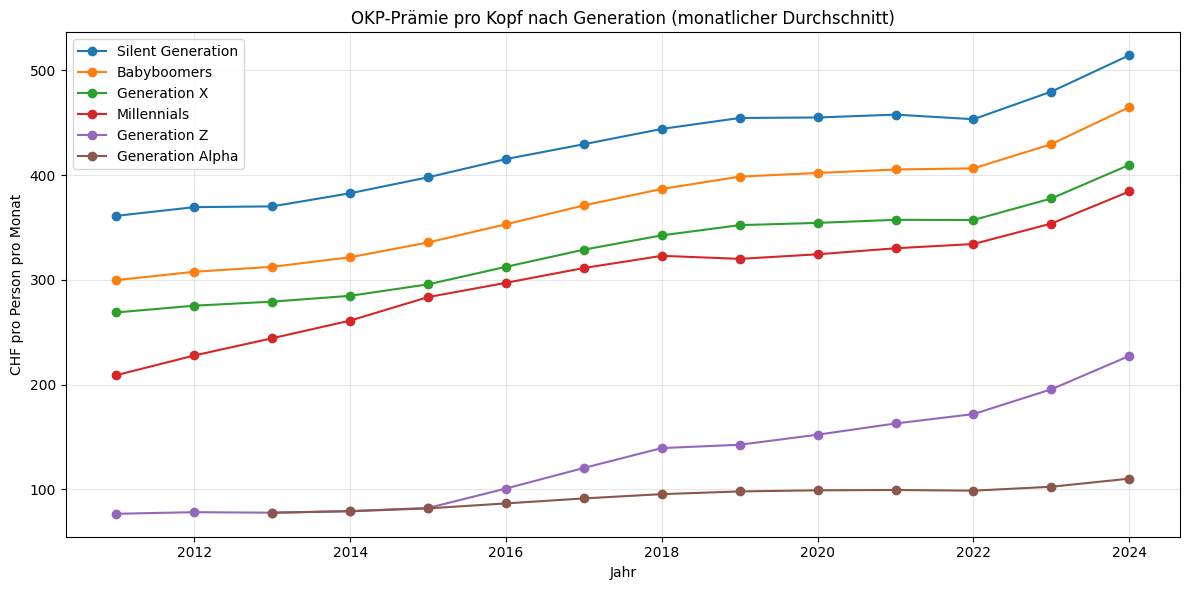

In [81]:
# Belastung durch Krankenkassenprämien
df_plot = okp[
    (okp['variable_name'] == 'okp_premium') &
    (okp['metric'] == 'per_capita_chf')
].copy()

# Jahreswert in Monatswert umrechnen
df_plot['value_monthly'] = df_plot['value'] / 12

gen_year = (
    df_plot
    .groupby(['project_age_group', 'project_age_order', 'year'])['value_monthly']
    .mean()
    .reset_index()
    .sort_values(['project_age_order', 'year'])
)

fig, ax = plt.subplots(figsize=(12, 6))

for gen in gen_year.sort_values('project_age_order')['project_age_group'].unique():
    subset = gen_year[gen_year['project_age_group'] == gen]
    ax.plot(subset['year'], subset['value_monthly'], marker='o', label=gen)

ax.set_title('OKP-Prämie pro Kopf nach Generation (monatlicher Durchschnitt)')
ax.set_xlabel('Jahr')
ax.set_ylabel('CHF pro Person pro Monat')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Methodische Einschränkung dieser Darstellung:**  
Der Wert für Generation Z und Generation Alpha ist verzerrt weil er Kinder mit Kindertarifen und junge Erwachsene mit Erwachsenentarifen vermischt.  
Der steil ansteigende Verlauf von Generation Z zeigt primär die Alterungsverschiebung der Kohorte – nicht einen realen Prämienanstieg.  
Das ist wichtig für die spätere Interpretation in der Visualisierung.

**Bemerkung: Bei den geleisteten Prämien sind in dieser Darstellung die Prämienverbilligung noch nicht abgezogen**

In [82]:
# VIZ 5: Stacked Area — Netto-OKP-Prämie vs. Gesundheitskosten nach Generation
# Generationen von unten nach oben (aufsteigend nach project_age_order)
GENS_STACK = [
    'Generation Alpha', 'Generation Z', 'Millennials', 
    'Generation X', 'Babyboomers', 'Silent Generation'
]

jahre_gemeinsam = sorted(
    set(okp['year'].unique()) & set(ahv_ein['year'].unique()) & set(ahv_aus['year'].unique())
)
idx = [0, len(jahre_gemeinsam)//3, 2*len(jahre_gemeinsam)//3, -1]
JAHRE = [jahre_gemeinsam[i] for i in idx]
GENS  = ['Generation Z', 'Millennials', 'Generation X', 'Babyboomers', 'Silent Generation']
BEZÜGER_GENS = ['Babyboomers', 'Silent Generation']

farben_gen = {
    'Silent Generation': '#4682B4',
    'Babyboomers':       '#FF8C00',
    'Generation X':      '#3CB371',
    'Millennials':       '#E9967A',
    'Generation Z':      '#7B68EE',
    'Generation Alpha':  '#A0522D',
}

def get_okp_val(variable, metric, gen, jahr):
    """Per-capita Jahreswert in Monatswert (chf_per_capita_year → /12)."""
    val = okp[
        (okp['variable_name'] == variable) &
        (okp['metric'] == metric) &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].mean()
    return (val / 12) if not pd.isna(val) else 0

def get_pv_per_versicherter(gen, jahr):
    """
    Prämienverbilligung pro Versicherten/Monat.
    = (total_mio_chf * 1_000_000) / n_versicherte / 12
    n_versicherte = beneficiaries_count / (beneficiary_rate / 100)
    """
    pv_total = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'total_mio_chf') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].sum()

    pv_count = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'beneficiaries_count') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].sum()

    pv_rate = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'beneficiary_rate') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].mean()

    if pd.isna(pv_rate) or pv_rate == 0 or pd.isna(pv_count) or pv_count == 0:
        return 0

    n_versicherte = pv_count / (pv_rate / 100)
    return (pv_total * 1_000_000) / n_versicherte / 12

def get_ahv_beitrag(gen, jahr):
    n = ahv_ein[
        (ahv_ein['metric'] == 'n_personen') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    s = ahv_ein[
        (ahv_ein['metric'] == 'sum_beitrag_ahv') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    return (s / n / 12) if n > 0 else 0

def get_ahv_rente(gen, jahr):
    """Gewichtete Durchschnittsrente pro Bezüger/Monat (nur für Bezüger-Generationen)."""
    if gen not in BEZÜGER_GENS:
        return 0
    aus_n  = ahv_aus[(ahv_aus['metric'] == 'anzahl_renten') &
                     (ahv_aus['project_age_group'] == gen) &
                     (ahv_aus['year'] == jahr)][['age','value']].rename(columns={'value':'n'})
    aus_mw = ahv_aus[(ahv_aus['metric'] == 'renten_mittelwert_chf') &
                     (ahv_aus['project_age_group'] == gen) &
                     (ahv_aus['year'] == jahr)][['age','value']].rename(columns={'value':'mw'})
    merged = aus_n.merge(aus_mw, on='age')
    if merged.empty or merged['n'].sum() == 0:
        return 0
    return (merged['mw'] * merged['n']).sum() / merged['n'].sum()

jahre_stack = jahre_gemeinsam  # 2012–2024, identisch zu VIZ 3



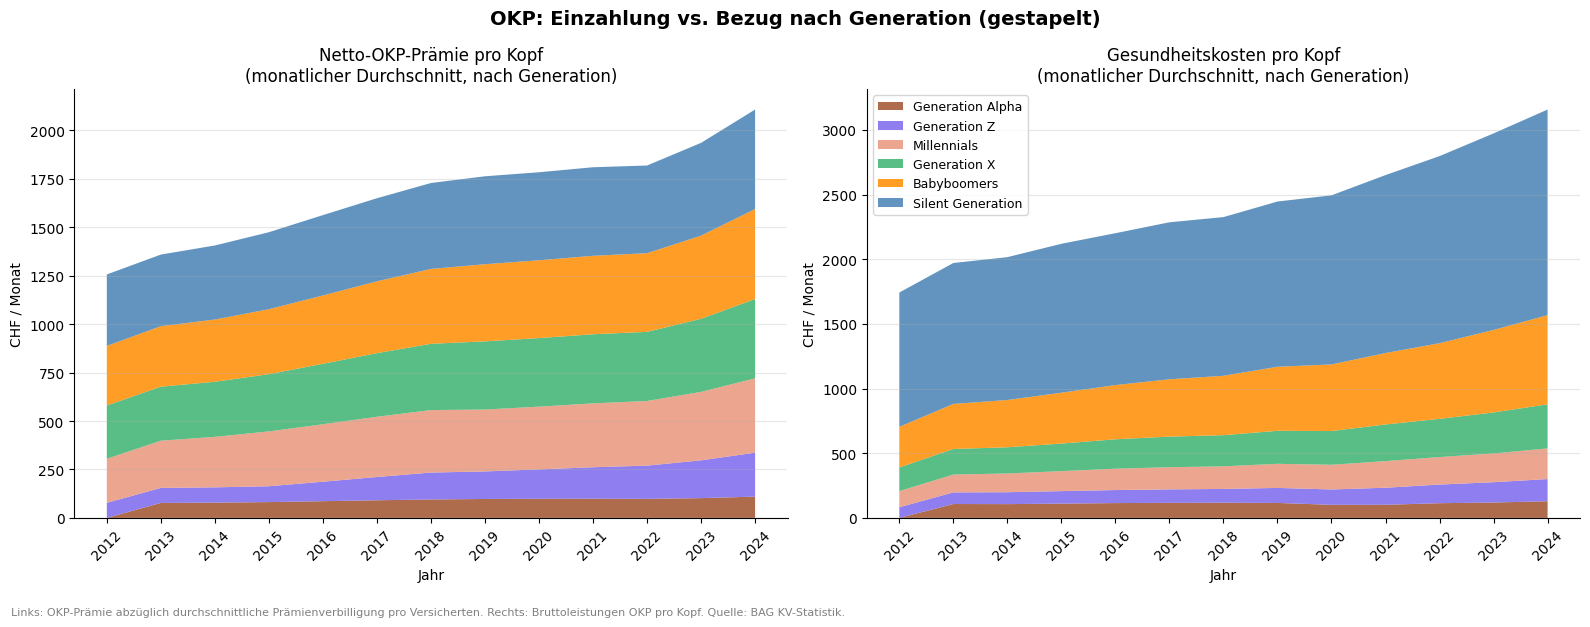

=== VIZ 5 Plausibilitätscheck 2024 ===
Generation            Netto-Prämie CHF/Mt  Gesundheitskosten CHF/Mt
-------------------------------------------------------------------
Generation Alpha                    109.8                     128.8
Generation Z                        226.8                     171.5
Millennials                         383.7                     236.9
Generation X                        409.2                     341.3
Babyboomers                         464.2                     689.2
Silent Generation                   513.5                    1590.2


In [83]:
# --- Daten berechnen ---
praemien_netto = []   # eine Liste pro Generation
kosten_brutto  = []

for gen in GENS_STACK:
    praemie_reihe = []
    kosten_reihe  = []
    for jahr in jahre_stack:
        praemie = get_okp_val('okp_premium', 'per_capita_chf', gen, jahr)
        pv      = get_pv_per_versicherter(gen, jahr)
        netto   = max(praemie - pv, 0)   # kein negativer Stack
        kosten  = get_okp_val('okp_bruttoleistungen', 'per_capita_chf', gen, jahr)
        praemie_reihe.append(netto)
        kosten_reihe.append(kosten)
    praemien_netto.append(praemie_reihe)
    kosten_brutto.append(kosten_reihe)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('OKP: Einzahlung vs. Bezug nach Generation (gestapelt)',
             fontsize=14, fontweight='bold')

colors = [farben_gen[g] for g in GENS_STACK]

ax1.stackplot(jahre_stack, praemien_netto,
              labels=GENS_STACK, colors=colors, alpha=0.85)
ax1.set_title('Netto-OKP-Prämie pro Kopf\n(monatlicher Durchschnitt, nach Generation)')
ax1.set_xlabel('Jahr')
ax1.set_ylabel('CHF / Monat')
ax1.set_xticks(jahre_stack)
ax1.tick_params(axis='x', rotation=45)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

ax2.stackplot(jahre_stack, kosten_brutto,
              labels=GENS_STACK, colors=colors, alpha=0.85)
ax2.set_title('Gesundheitskosten pro Kopf\n(monatlicher Durchschnitt, nach Generation)')
ax2.set_xlabel('Jahr')
ax2.set_ylabel('CHF / Monat')
ax2.set_xticks(jahre_stack)
ax2.tick_params(axis='x', rotation=45)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper left', fontsize=9)

fig.text(0.01, -0.03,
         'Links: OKP-Prämie abzüglich durchschnittliche Prämienverbilligung pro Versicherten. '
         'Rechts: Bruttoleistungen OKP pro Kopf. Quelle: BAG KV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Plausibilitätscheck 2024
print('=== VIZ 5 Plausibilitätscheck 2024 ===')
print(f'{"Generation":<20} {"Netto-Prämie CHF/Mt":>20} {"Gesundheitskosten CHF/Mt":>25}')
print('-' * 67)
for gen, p_reihe, k_reihe in zip(GENS_STACK, praemien_netto, kosten_brutto):
    idx_2024 = jahre_stack.index(2024)
    print(f'{gen:<20} {p_reihe[idx_2024]:>20.1f} {k_reihe[idx_2024]:>25.1f}')

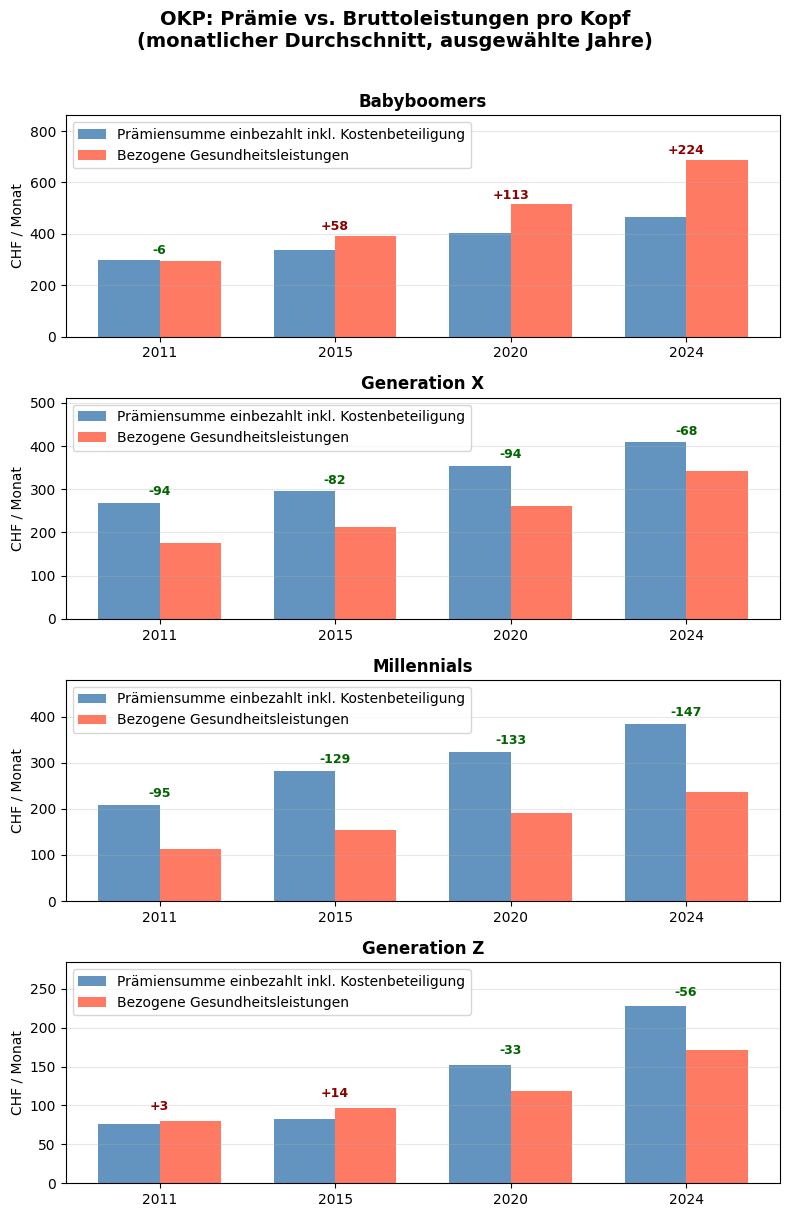

In [84]:
generationen = ['Babyboomers', 'Generation X', 'Millennials', 'Generation Z']
okp_jahre = sorted(
    set(okp[(okp['variable_name'] == 'okp_premium') & (okp['metric'] == 'per_capita_chf')]['year'].unique()) &
    set(okp[(okp['variable_name'] == 'okp_bruttoleistungen') & (okp['metric'] == 'per_capita_chf')]['year'].unique())
)
idx = [0, len(okp_jahre)//3, 2*len(okp_jahre)//3, -1]
jahre = [okp_jahre[i] for i in idx]

fig, axes = plt.subplots(4, 1, figsize=(8, 12))
fig.suptitle('OKP: Prämie vs. Bruttoleistungen pro Kopf\n(monatlicher Durchschnitt, ausgewählte Jahre)', 
             fontsize=14, fontweight='bold', y=1.01)

for idx, gen in enumerate(generationen):
    ax = axes[idx]
    
    praemien = []
    leistungen = []
    
    for jahr in jahre:
        # Prämie pro Kopf/Monat
        p = okp[
            (okp['variable_name'] == 'okp_premium') &
            (okp['metric'] == 'per_capita_chf') &
            (okp['project_age_group'] == gen) &
            (okp['year'] == jahr)
        ]['value'].mean() / 12
        
        # Bruttoleistung pro Kopf/Monat
        l = okp[
            (okp['variable_name'] == 'okp_bruttoleistungen') &
            (okp['metric'] == 'per_capita_chf') &
            (okp['project_age_group'] == gen) &
            (okp['year'] == jahr)
        ]['value'].mean() / 12
        
        praemien.append(p)
        leistungen.append(l)
    
    x = range(len(jahre))
    breite = 0.35
    
    balken_p = ax.bar([i - breite/2 for i in x], praemien, 
                       breite, label='Prämiensumme einbezahlt inkl. Kostenbeteiligung', color='steelblue', alpha=0.85)
    balken_l = ax.bar([i + breite/2 for i in x], leistungen, 
                       breite, label='Bezogene Gesundheitsleistungen', color='tomato', alpha=0.85)
    
    # Fehlbetrag als Beschriftung
    for i, (p, l) in enumerate(zip(praemien, leistungen)):
        differenz = l - p
        farbe = 'darkred' if differenz > 0 else 'darkgreen'
        symbol = '+' if differenz > 0 else ''
        ax.text(i, max(p, l) + 10, f'{symbol}{differenz:.0f}', 
                ha='center', va='bottom', fontsize=9, color=farbe, fontweight='bold')
    
    ax.set_title(gen, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(j) for j in jahre])
    ax.set_ylabel('CHF / Monat')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(max(praemien), max(leistungen)) * 1.25)

plt.tight_layout()
plt.show()

In [85]:
netto_cashflow = []
for gen in GENS_STACK:
    reihe = []
    for jahr in jahre_stack:
        praemie  = get_okp_val('okp_premium', 'per_capita_chf', gen, jahr)
        pv       = get_pv_per_versicherter(gen, jahr)
        kosten   = get_okp_val('okp_bruttoleistungen', 'per_capita_chf', gen, jahr)
        netto    = kosten - max(praemie - pv, 0)
        reihe.append(netto)
    netto_cashflow.append(reihe)

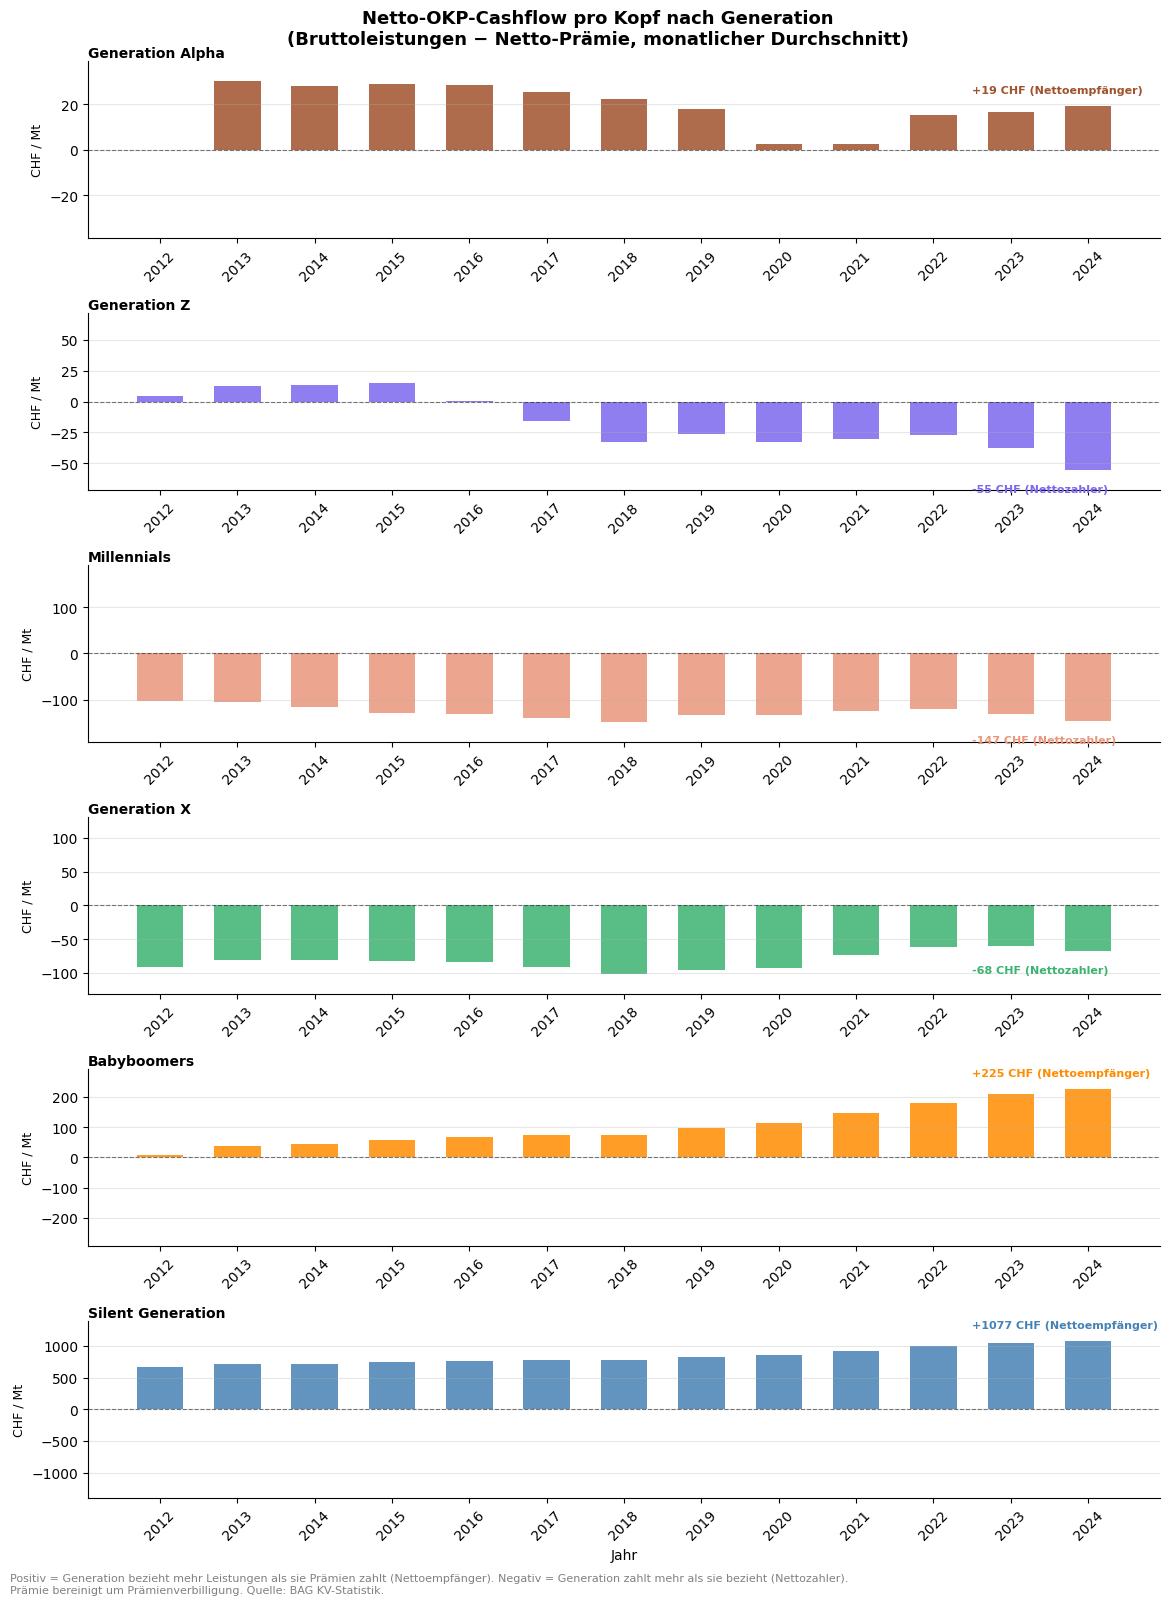

In [86]:
# VIZ 6c: Netto-OKP-Cashflow pro Generation — Balken, individuelle Y-Achse

fig, axes = plt.subplots(len(GENS_STACK), 1, figsize=(12, 16), sharex=False)
fig.suptitle('Netto-OKP-Cashflow pro Kopf nach Generation\n'
             '(Bruttoleistungen − Netto-Prämie, monatlicher Durchschnitt)',
             fontsize=13, fontweight='bold')

for i, (gen, reihe) in enumerate(zip(GENS_STACK, netto_cashflow)):
    ax = axes[i]
    farbe = farben_gen[gen]
    werte = np.array(reihe)

    # Balken: positiv nach oben, negativ nach unten
    farben_balken = [farbe if v >= 0 else farbe for v in werte]
    ax.bar(jahre_stack, werte, color=farbe, alpha=0.85, width=0.6)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Y-Achse: symmetrisch um 0, mit etwas Puffer
    ymax = max(abs(werte.max()), abs(werte.min())) * 1.3
    ymax = max(ymax, 10)   # Minimum damit Gen Alpha sichtbar bleibt
    ax.set_ylim(-ymax, ymax)

    ax.set_ylabel('CHF / Mt', fontsize=9)
    ax.set_title(gen, fontweight='bold', fontsize=10, loc='left', pad=3)
    ax.set_xticks(jahre_stack)
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    # 2024-Wert annotieren
    val_2024 = reihe[jahre_stack.index(2024)]
    label = 'Nettoempfänger' if val_2024 > 0 else 'Nettozahler'
    y_offset = ymax * 0.15 if val_2024 >= 0 else -ymax * 0.25
    ax.annotate(f'{val_2024:+.0f} CHF ({label})',
                xy=(2024, val_2024),
                xytext=(2022.5, val_2024 + y_offset),
                fontsize=8, color=farbe, fontweight='bold')

axes[-1].set_xlabel('Jahr', fontsize=10)

fig.text(0.01, -0.01,
         'Positiv = Generation bezieht mehr Leistungen als sie Prämien zahlt (Nettoempfänger). '
         'Negativ = Generation zahlt mehr als sie bezieht (Nettozahler).\n'
         'Prämie bereinigt um Prämienverbilligung. Quelle: BAG KV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [87]:
AHV_SATZ = 0.087

def get_bruttolohn(gen, jahr):
    n = ahv_ein[
        (ahv_ein['metric'] == 'n_personen') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    s = ahv_ein[
        (ahv_ein['metric'] == 'sum_beitrag_ahv') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    if n == 0:
        return 0
    return (s / n) / AHV_SATZ / 12

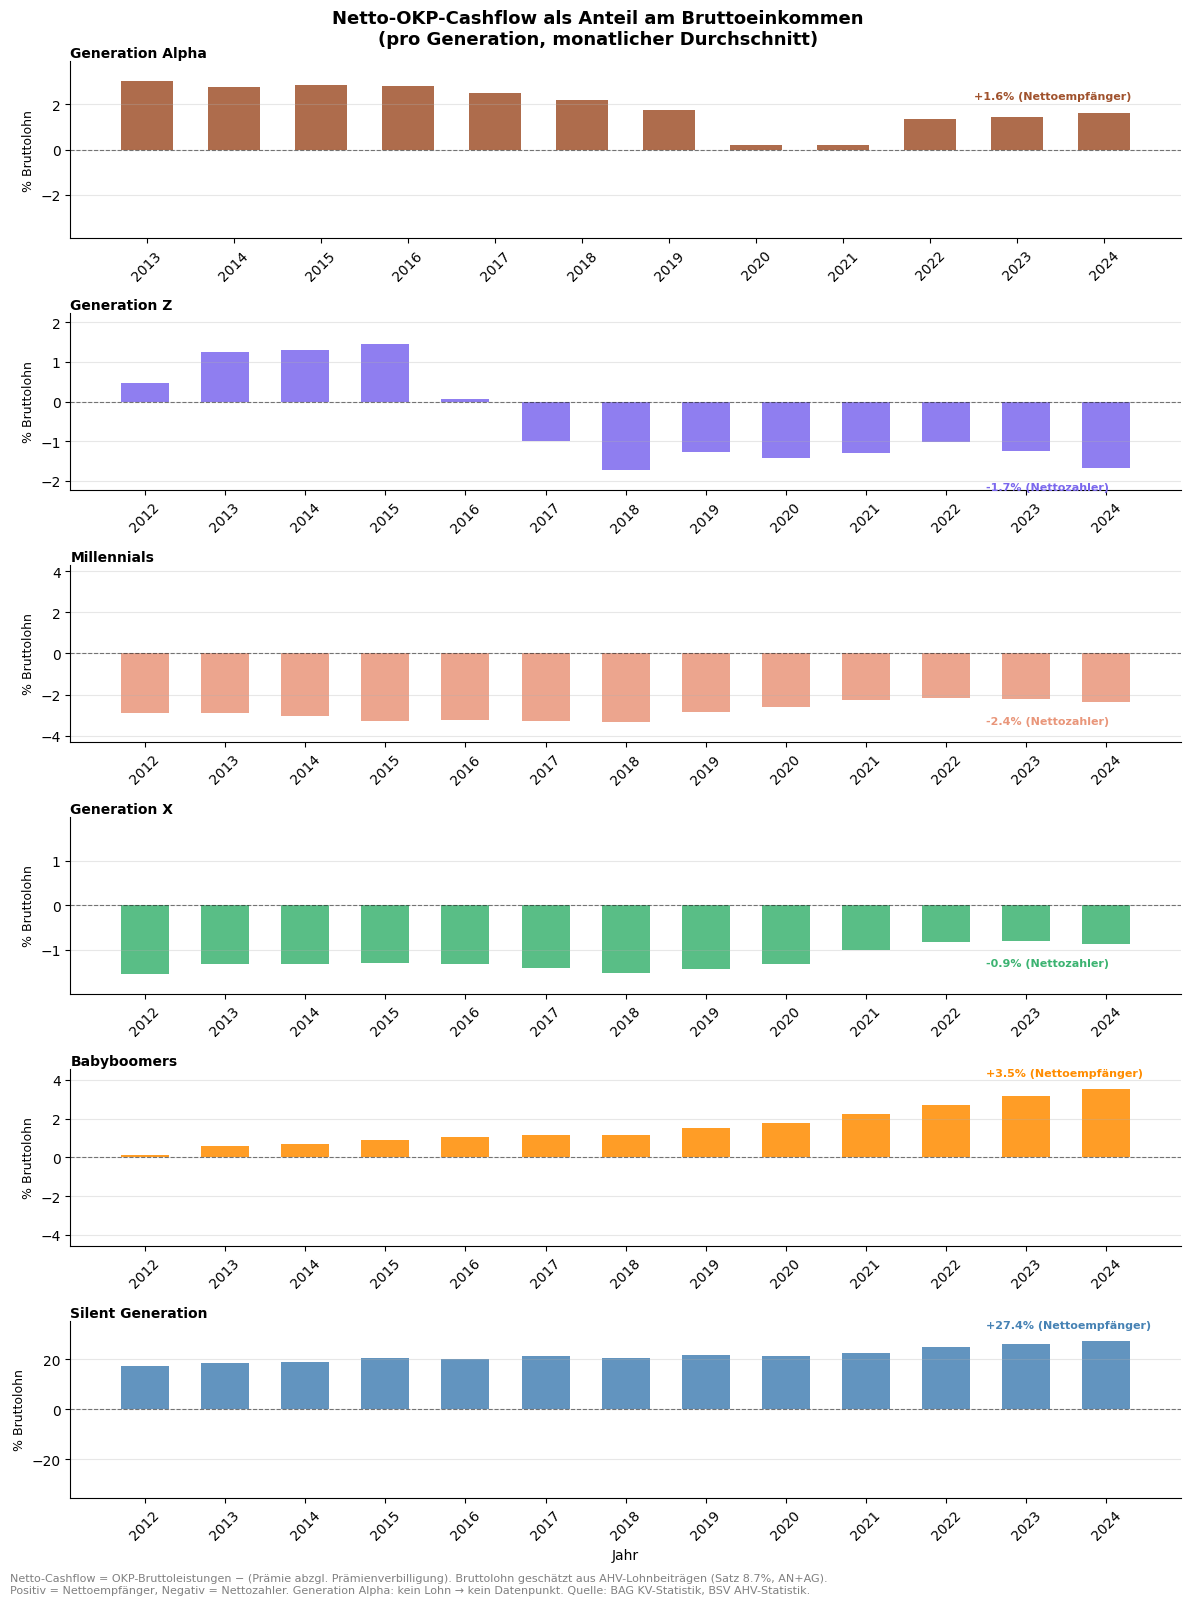

=== VIZ 7 Plausibilitätscheck 2024 ===
Generation            Lohn CHF/Mt  Cashflow CHF/Mt   Anteil %
--------------------------------------------------------------
Generation Alpha             1162             19.0      +1.6%
Generation Z                 3286            -55.3      -1.7%
Millennials                  6189           -146.8      -2.4%
Generation X                 7789            -67.9      -0.9%
Babyboomers                  6385            225.0      +3.5%
Silent Generation            3933           1076.7     +27.4%


In [88]:
# VIZ 7: Netto-OKP-Cashflow als % des Bruttoeinkommens — pro Generation

# Daten berechnen
cashflow_pct = []

for gen, reihe in zip(GENS_STACK, netto_cashflow):
    pct_reihe = []
    for jahr, netto in zip(jahre_stack, reihe):
        lohn = get_bruttolohn(gen, jahr)
        if lohn > 0:
            pct_reihe.append(netto / lohn * 100)
        else:
            pct_reihe.append(None)   # kein Lohn → kein Datenpunkt (z.B. Gen Alpha)
    cashflow_pct.append(pct_reihe)

# Plot
fig, axes = plt.subplots(len(GENS_STACK), 1, figsize=(12, 16), sharex=False)
fig.suptitle('Netto-OKP-Cashflow als Anteil am Bruttoeinkommen\n'
             '(pro Generation, monatlicher Durchschnitt)',
             fontsize=13, fontweight='bold')

for i, (gen, pct_reihe) in enumerate(zip(GENS_STACK, cashflow_pct)):
    ax = axes[i]
    farbe = farben_gen[gen]

    # Nur Jahre mit gültigen Werten
    jahre_valid = [j for j, v in zip(jahre_stack, pct_reihe) if v is not None]
    werte_valid = [v for v in pct_reihe if v is not None]

    if not werte_valid:
        ax.set_title(f'{gen} — keine Einkommensdaten', fontweight='bold',
                     fontsize=10, loc='left', pad=3)
        ax.set_visible(True)
        continue

    werte_arr = np.array(werte_valid)
    ax.bar(jahre_valid, werte_arr, color=farbe, alpha=0.85, width=0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Y-Achse individuell skalieren
    ymax = max(abs(werte_arr.max()), abs(werte_arr.min())) * 1.3
    ymax = max(ymax, 1)
    ax.set_ylim(-ymax, ymax)

    ax.set_ylabel('% Bruttolohn', fontsize=9)
    ax.set_title(gen, fontweight='bold', fontsize=10, loc='left', pad=3)
    ax.set_xticks(jahre_valid)
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    # 2024-Wert annotieren falls vorhanden
    if 2024 in jahre_valid:
        val_2024 = werte_valid[jahre_valid.index(2024)]
        label = 'Nettoempfänger' if val_2024 > 0 else 'Nettozahler'
        y_offset = ymax * 0.15 if val_2024 >= 0 else -ymax * 0.25
        ax.annotate(f'{val_2024:+.1f}% ({label})',
                    xy=(2024, val_2024),
                    xytext=(2022.5, val_2024 + y_offset),
                    fontsize=8, color=farbe, fontweight='bold')

axes[-1].set_xlabel('Jahr', fontsize=10)

fig.text(0.01, -0.01,
         'Netto-Cashflow = OKP-Bruttoleistungen − (Prämie abzgl. Prämienverbilligung). '
         'Bruttolohn geschätzt aus AHV-Lohnbeiträgen (Satz 8.7%, AN+AG).\n'
         'Positiv = Nettoempfänger, Negativ = Nettozahler. '
         'Generation Alpha: kein Lohn → kein Datenpunkt. Quelle: BAG KV-Statistik, BSV AHV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Plausibilitätscheck 2024
print('=== VIZ 7 Plausibilitätscheck 2024 ===')
print(f'{"Generation":<20} {"Lohn CHF/Mt":>12} {"Cashflow CHF/Mt":>16} {"Anteil %":>10}')
print('-' * 62)
for gen, reihe, pct_reihe in zip(GENS_STACK, netto_cashflow, cashflow_pct):
    if 2024 not in jahre_stack:
        continue
    idx = jahre_stack.index(2024)
    lohn = get_bruttolohn(gen, 2024)
    cf   = reihe[idx]
    pct  = pct_reihe[idx]
    pct_str = f'{pct:+.1f}%' if pct is not None else 'n/a'
    print(f'{gen:<20} {lohn:>12.0f} {cf:>16.1f} {pct_str:>10}')

## Who pays - Social Transfer Costs

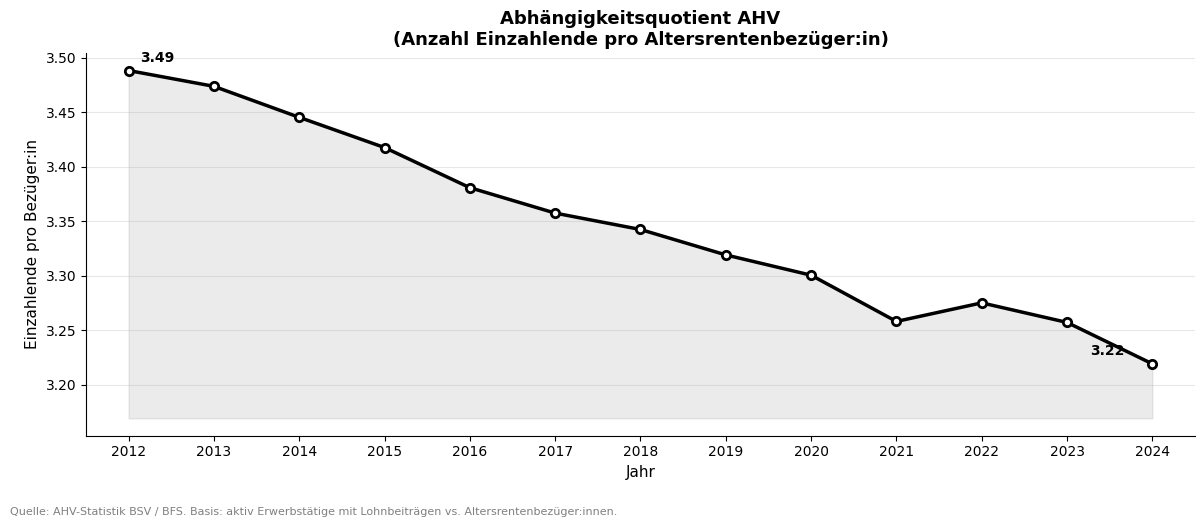

In [89]:
# VIZ 2: Abhängigkeitsquotient AHV (Liniendiagramm)
# Basis: verhaeltnis-DataFrame aus Cell 18

jahr_min = int(verhaeltnis['year'].min())
viz2_data = verhaeltnis[verhaeltnis['year'] >= jahr_min].copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(viz2_data['year'], viz2_data['ratio'],
        color='black', linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=2)

ax.fill_between(viz2_data['year'], viz2_data['ratio'], viz2_data['ratio'].min() - 0.05,
                color='black', alpha=0.08)

# Erste und letzte Datenpunkte beschriften
for idx in [0, -1]:
    row = viz2_data.iloc[idx]
    ax.annotate(f"{row['ratio']:.2f}",
                xy=(row['year'], row['ratio']),
                xytext=(8 if idx == 0 else -45, 6),
                textcoords='offset points',
                fontsize=10, fontweight='bold', color='black')

ax.set_xlim(2011.5, 2024.5)
ax.set_xticks(viz2_data['year'])
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Einzahlende pro Bezüger:in', fontsize=11)
ax.set_title('Abhängigkeitsquotient AHV\n(Anzahl Einzahlende pro Altersrentenbezüger:in)',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

fig.text(0, -0.04,
         'Quelle: AHV-Statistik BSV / BFS. Basis: aktiv Erwerbstätige mit Lohnbeiträgen vs. Altersrentenbezüger:innen.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()

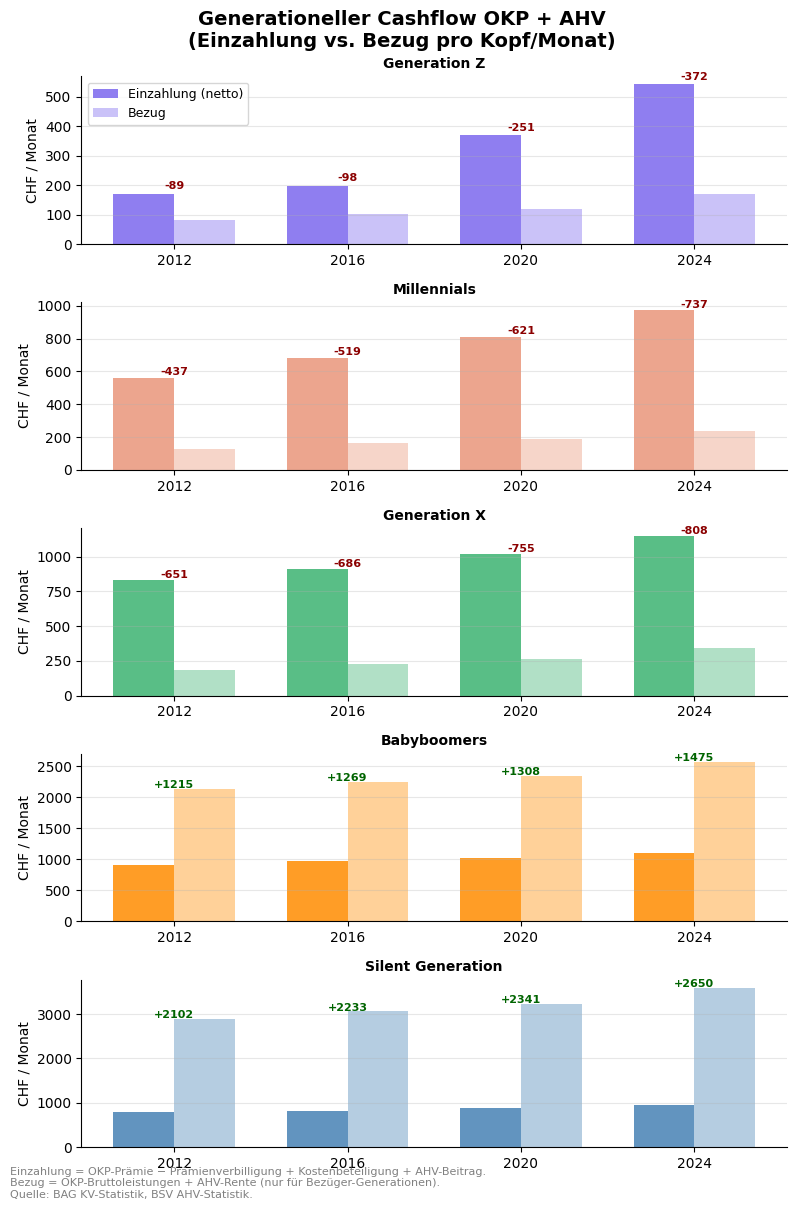

In [90]:
# VIZ 3: Kombinierter Cashflow OKP + AHV nach Generation (ausgewählte Jahre)
# Methode:
# Einzahlung (negativ): OKP-Prämie - Prämienverbilligung (pro Versicherten) + OKP-Kostenbeteiligung + AHV-Beitrag
# Bezug (positiv):      OKP-Bruttoleistungen (pro Versicherten) + AHV-Rente (nur für Bezüger-Generationen)

jahre_gemeinsam = sorted(
    set(okp['year'].unique()) & set(ahv_ein['year'].unique()) & set(ahv_aus['year'].unique())
)
idx = [0, len(jahre_gemeinsam)//3, 2*len(jahre_gemeinsam)//3, -1]
JAHRE = [jahre_gemeinsam[i] for i in idx]
GENS  = ['Generation Z', 'Millennials', 'Generation X', 'Babyboomers', 'Silent Generation']
BEZÜGER_GENS = ['Babyboomers', 'Silent Generation']

farben = {
    'Generation Z':    '#7B68EE',
    'Millennials':     '#E9967A',
    'Generation X':    '#3CB371',
    'Babyboomers':     '#FF8C00',
    'Silent Generation': '#4682B4',
}

def get_okp_val(variable, metric, gen, jahr):
    """Per-capita Jahreswert in Monatswert (chf_per_capita_year → /12)."""
    val = okp[
        (okp['variable_name'] == variable) &
        (okp['metric'] == metric) &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].mean()
    return (val / 12) if not pd.isna(val) else 0

def get_pv_per_versicherter(gen, jahr):
    """
    Prämienverbilligung pro Versicherten/Monat.
    = (total_mio_chf * 1_000_000) / n_versicherte / 12
    n_versicherte = beneficiaries_count / (beneficiary_rate / 100)
    """
    pv_total = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'total_mio_chf') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].sum()

    pv_count = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'beneficiaries_count') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].sum()

    pv_rate = okp[
        (okp['variable_name'] == 'praemienverbilligung') &
        (okp['metric'] == 'beneficiary_rate') &
        (okp['project_age_group'] == gen) &
        (okp['year'] == jahr)
    ]['value'].mean()

    if pd.isna(pv_rate) or pv_rate == 0 or pd.isna(pv_count) or pv_count == 0:
        return 0

    n_versicherte = pv_count / (pv_rate / 100)
    return (pv_total * 1_000_000) / n_versicherte / 12

def get_ahv_beitrag(gen, jahr):
    n = ahv_ein[
        (ahv_ein['metric'] == 'n_personen') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    s = ahv_ein[
        (ahv_ein['metric'] == 'sum_beitrag_ahv') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    return (s / n / 12) if n > 0 else 0

def get_ahv_rente(gen, jahr):
    """Gewichtete Durchschnittsrente pro Bezüger/Monat (nur für Bezüger-Generationen)."""
    if gen not in BEZÜGER_GENS:
        return 0
    aus_n  = ahv_aus[(ahv_aus['metric'] == 'anzahl_renten') &
                     (ahv_aus['project_age_group'] == gen) &
                     (ahv_aus['year'] == jahr)][['age','value']].rename(columns={'value':'n'})
    aus_mw = ahv_aus[(ahv_aus['metric'] == 'renten_mittelwert_chf') &
                     (ahv_aus['project_age_group'] == gen) &
                     (ahv_aus['year'] == jahr)][['age','value']].rename(columns={'value':'mw'})
    merged = aus_n.merge(aus_mw, on='age')
    if merged.empty or merged['n'].sum() == 0:
        return 0
    return (merged['mw'] * merged['n']).sum() / merged['n'].sum()

# --- Daten berechnen ---
data = {}
for gen in GENS:
    data[gen] = {'einzahlung': [], 'bezug': [], 'netto': []}
    for jahr in JAHRE:
        praemie   = get_okp_val('okp_premium',        'per_capita_chf', gen, jahr)
        pv        = get_pv_per_versicherter(gen, jahr)
        kosten    = get_okp_val('okp_kostenbeteiligung', 'per_capita_chf', gen, jahr)
        leistung  = get_okp_val('okp_bruttoleistungen',  'per_capita_chf', gen, jahr)
        ahv_b     = get_ahv_beitrag(gen, jahr)
        ahv_r     = get_ahv_rente(gen, jahr)

        einzahlung = praemie - pv + kosten + ahv_b   # was die Generation ins System gibt
        bezug      = leistung + ahv_r                 # was sie aus dem System erhält
        netto      = bezug - einzahlung               # positiv = Nettoempfänger

        data[gen]['einzahlung'].append(einzahlung)
        data[gen]['bezug'].append(bezug)
        data[gen]['netto'].append(netto)

# --- Plot ---
fig, axes = plt.subplots(len(GENS), 1, figsize=(8, 12), sharex=False)
fig.suptitle('Generationeller Cashflow OKP + AHV\n(Einzahlung vs. Bezug pro Kopf/Monat)',
             fontsize=14, fontweight='bold')

x      = np.arange(len(JAHRE))
breite = 0.35

for idx, gen in enumerate(GENS):
    ax = axes[idx]
    farbe = farben[gen]

    b_ein = ax.bar(x - breite/2, data[gen]['einzahlung'], breite,
                   label='Einzahlung (netto)', color=farbe, alpha=0.85)
    b_bez = ax.bar(x + breite/2, data[gen]['bezug'],      breite,
                   label='Bezug', color=farbe, alpha=0.4)

    # Netto-Differenz annotieren
    for i, (e, b) in enumerate(zip(data[gen]['einzahlung'], data[gen]['bezug'])):
        netto = b - e
        farbe_n = 'darkgreen' if netto > 0 else 'darkred'
        symbol  = '+' if netto > 0 else ''
        ax.text(x[i], max(e, b) + 15, f'{symbol}{netto:.0f}',
                ha='center', fontsize=8, color=farbe_n, fontweight='bold')

    ax.set_title(gen, fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([str(j) for j in JAHRE])
    ax.set_ylabel('CHF / Monat')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

fig.text(0.01, -0.01,
         'Einzahlung = OKP-Prämie − Prämienverbilligung + Kostenbeteiligung + AHV-Beitrag.\n'
         'Bezug = OKP-Bruttoleistungen + AHV-Rente (nur für Bezüger-Generationen).\n'
         'Quelle: BAG KV-Statistik, BSV AHV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
# plt.savefig('viz3_cashflow_okp_ahv.png', dpi=150, bbox_inches='tight')
plt.show()

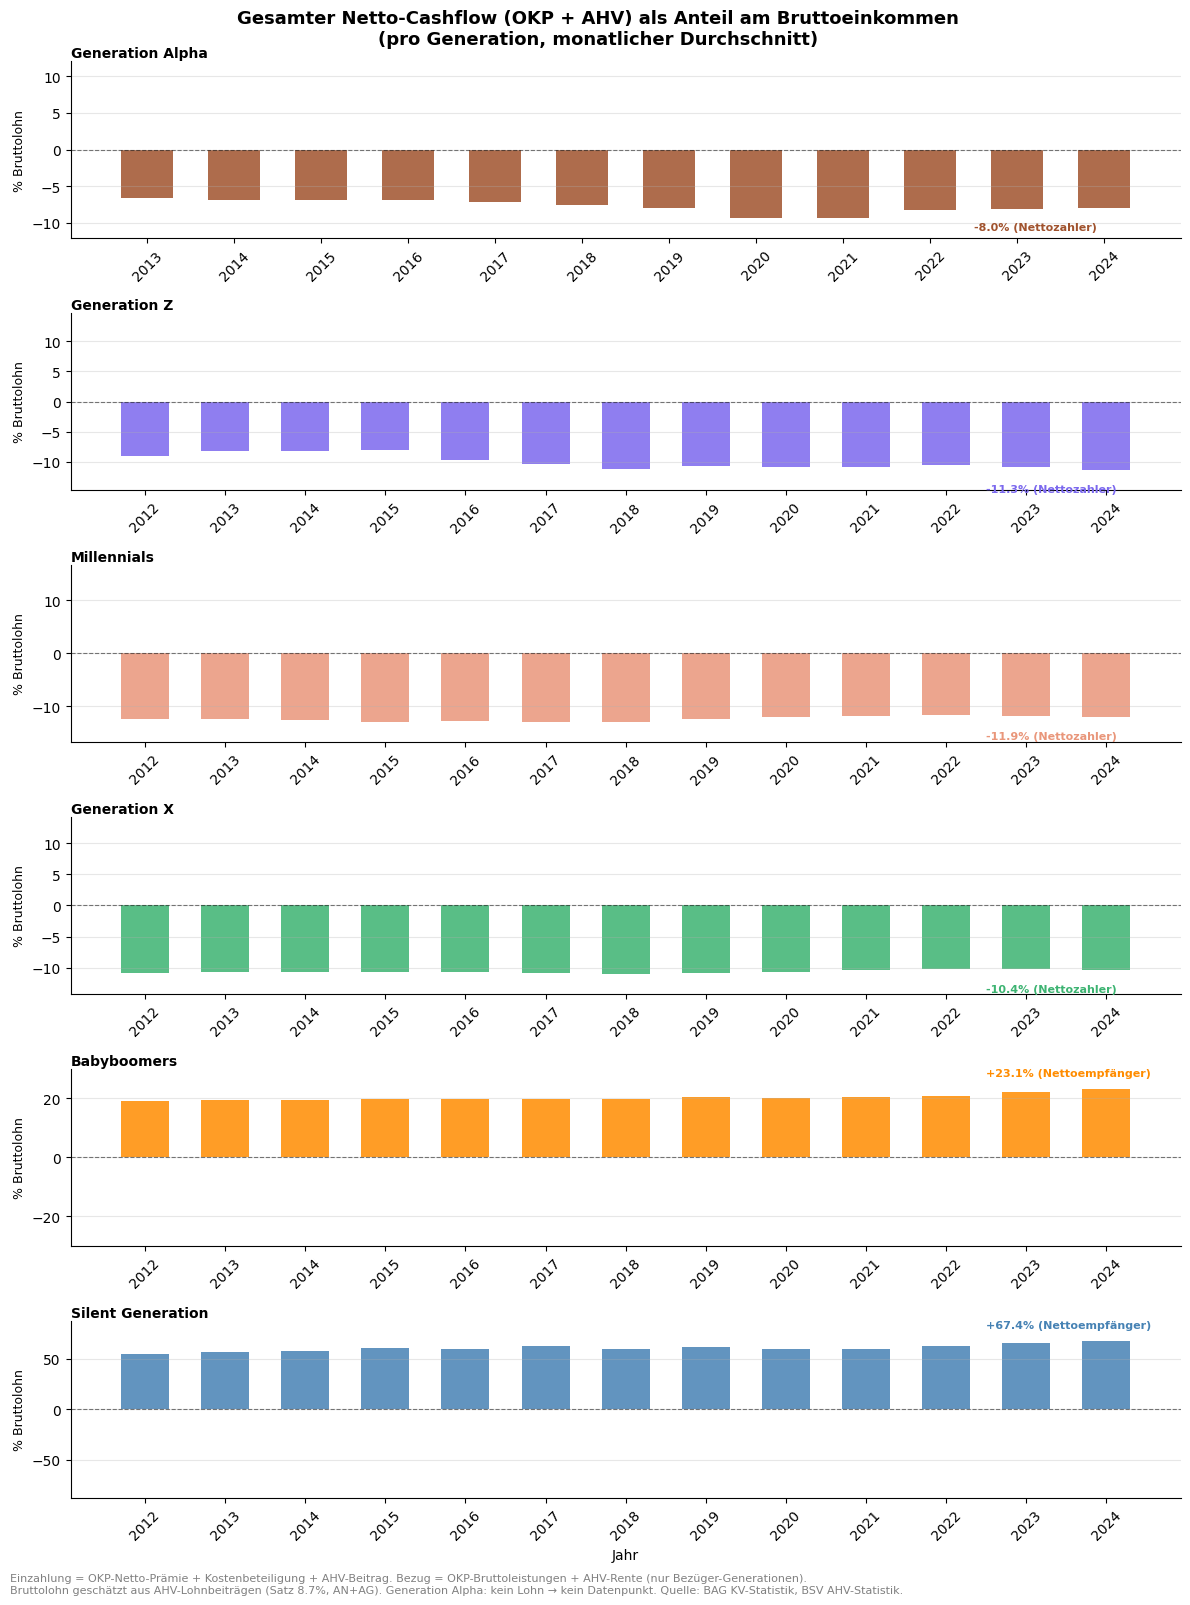

=== VIZ 7b Plausibilitätscheck 2024 ===
Generation            Lohn CHF/Mt   Einzahlung    Bezug  Netto CHF   Anteil %
----------------------------------------------------------------------------
Generation Alpha             1162          222      129        -93      -8.0%
Generation Z                 3286          543      171       -372     -11.3%
Millennials                  6189          974      237       -737     -11.9%
Generation X                 7789         1149      341       -808     -10.4%
Babyboomers                  6385         1094     2569       1475     +23.1%
Silent Generation            3933          948     3597       2650     +67.4%


In [91]:
# VIZ 7b: Gesamter Netto-Cashflow (OKP + AHV) als % des Bruttoeinkommens — pro Generation
# Einzahlung = OKP-Netto-Prämie + OKP-Kostenbeteiligung + AHV-Beitrag
# Bezug      = OKP-Bruttoleistungen + AHV-Rente (nur Bezüger-Generationen)
# Netto      = Bezug - Einzahlung → positiv = Nettoempfänger, negativ = Nettozahler

cashflow_gesamt_pct = []
cashflow_gesamt_abs = []

for gen in GENS_STACK:
    pct_reihe = []
    abs_reihe = []
    for jahr in jahre_stack:
        praemie  = get_okp_val('okp_premium',           'per_capita_chf', gen, jahr)
        pv       = get_pv_per_versicherter(gen, jahr)
        kosten   = get_okp_val('okp_kostenbeteiligung', 'per_capita_chf', gen, jahr)
        leistung = get_okp_val('okp_bruttoleistungen',  'per_capita_chf', gen, jahr)
        ahv_b    = get_ahv_beitrag(gen, jahr)
        ahv_r    = get_ahv_rente(gen, jahr)
        lohn     = get_bruttolohn(gen, jahr)

        einzahlung = max(praemie - pv, 0) + kosten + ahv_b
        bezug      = leistung + ahv_r
        netto      = bezug - einzahlung   # positiv = Nettoempfänger

        abs_reihe.append(netto)

        if lohn > 0:
            pct_reihe.append(netto / lohn * 100)
        else:
            pct_reihe.append(None)

    cashflow_gesamt_abs.append(abs_reihe)
    cashflow_gesamt_pct.append(pct_reihe)

# --- Plot ---
fig, axes = plt.subplots(len(GENS_STACK), 1, figsize=(12, 16), sharex=False)
fig.suptitle('Gesamter Netto-Cashflow (OKP + AHV) als Anteil am Bruttoeinkommen\n'
             '(pro Generation, monatlicher Durchschnitt)',
             fontsize=13, fontweight='bold')

for i, (gen, pct_reihe) in enumerate(zip(GENS_STACK, cashflow_gesamt_pct)):
    ax = axes[i]
    farbe = farben_gen[gen]

    jahre_valid = [j for j, v in zip(jahre_stack, pct_reihe) if v is not None]
    werte_valid = [v for v in pct_reihe if v is not None]

    if not werte_valid:
        ax.set_title(f'{gen} — keine Einkommensdaten', fontweight='bold',
                     fontsize=10, loc='left', pad=3)
        continue

    werte_arr = np.array(werte_valid)
    ax.bar(jahre_valid, werte_arr, color=farbe, alpha=0.85, width=0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    ymax = max(abs(werte_arr.max()), abs(werte_arr.min())) * 1.3
    ymax = max(ymax, 1)
    ax.set_ylim(-ymax, ymax)

    ax.set_ylabel('% Bruttolohn', fontsize=9)
    ax.set_title(gen, fontweight='bold', fontsize=10, loc='left', pad=3)
    ax.set_xticks(jahre_valid)
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    if 2024 in jahre_valid:
        val_2024 = werte_valid[jahre_valid.index(2024)]
        label = 'Nettoempfänger' if val_2024 > 0 else 'Nettozahler'
        y_offset = ymax * 0.15 if val_2024 >= 0 else -ymax * 0.25
        ax.annotate(f'{val_2024:+.1f}% ({label})',
                    xy=(2024, val_2024),
                    xytext=(2022.5, val_2024 + y_offset),
                    fontsize=8, color=farbe, fontweight='bold')

axes[-1].set_xlabel('Jahr', fontsize=10)

fig.text(0.01, -0.01,
         'Einzahlung = OKP-Netto-Prämie + Kostenbeteiligung + AHV-Beitrag. '
         'Bezug = OKP-Bruttoleistungen + AHV-Rente (nur Bezüger-Generationen).\n'
         'Bruttolohn geschätzt aus AHV-Lohnbeiträgen (Satz 8.7%, AN+AG). '
         'Generation Alpha: kein Lohn → kein Datenpunkt. Quelle: BAG KV-Statistik, BSV AHV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Plausibilitätscheck 2024
print('=== VIZ 7b Plausibilitätscheck 2024 ===')
print(f'{"Generation":<20} {"Lohn CHF/Mt":>12} {"Einzahlung":>12} {"Bezug":>8} {"Netto CHF":>10} {"Anteil %":>10}')
print('-' * 76)
for gen, abs_reihe, pct_reihe in zip(GENS_STACK, cashflow_gesamt_abs, cashflow_gesamt_pct):
    if 2024 not in jahre_stack:
        continue
    idx  = jahre_stack.index(2024)
    lohn = get_bruttolohn(gen, 2024)
    netto = abs_reihe[idx]
    pct   = pct_reihe[idx]
    pct_str = f'{pct:+.1f}%' if pct is not None else 'n/a'
    # Einzahlung/Bezug aufschlüsseln
    praemie  = get_okp_val('okp_premium',           'per_capita_chf', gen, 2024)
    pv       = get_pv_per_versicherter(gen, 2024)
    kosten   = get_okp_val('okp_kostenbeteiligung', 'per_capita_chf', gen, 2024)
    leistung = get_okp_val('okp_bruttoleistungen',  'per_capita_chf', gen, 2024)
    ahv_b    = get_ahv_beitrag(gen, 2024)
    ahv_r    = get_ahv_rente(gen, 2024)
    einz = max(praemie - pv, 0) + kosten + ahv_b
    bezug = leistung + ahv_r
    print(f'{gen:<20} {lohn:>12.0f} {einz:>12.0f} {bezug:>8.0f} {netto:>10.0f} {pct_str:>10}')

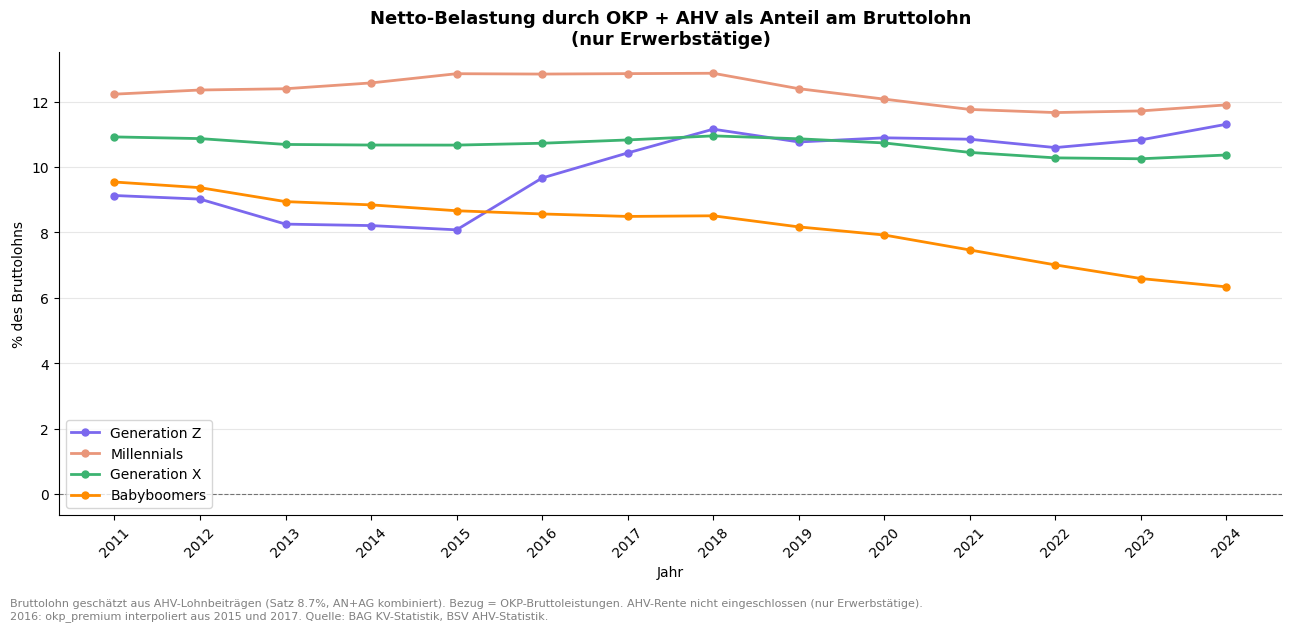

In [92]:
# VIZ 4: Prozentuale monatliche Belastung des Cashflows (nur Erwerbstätige)
# Methode:
# Bruttolohn/Monat = sum_beitrag_ahv / n_personen / 0.087 / 12
# Belastung % = (Einzahlung - Bezug) / Bruttolohn * 100
# Einzahlung = OKP-Prämie - Prämienverbilligung + Kostenbeteiligung + AHV-Beitrag
# Bezug = OKP-Bruttoleistungen (AHV-Rente wird hier ausgeschlossen)

JAHRE_VIZ4 = sorted(
    set(okp[(okp['variable_name'] == 'okp_premium') & (okp['metric'] == 'per_capita_chf')]['year'].unique()) &
    set(ahv_ein['year'].unique())
)
AHV_SATZ   = 0.087  # Arbeitnehmer + Arbeitgeber kombiniert
GENS_VIZ4  = ['Generation Z', 'Millennials', 'Generation X', 'Babyboomers']

farben_viz4 = {
    'Generation Z':  '#7B68EE',
    'Millennials':   '#E9967A',
    'Generation X':  '#3CB371',
    'Babyboomers':   '#FF8C00',
}

def get_bruttolohn(gen, jahr):
    n = ahv_ein[
        (ahv_ein['metric'] == 'n_personen') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    s = ahv_ein[
        (ahv_ein['metric'] == 'sum_beitrag_ahv') &
        (ahv_ein['project_age_group'] == gen) &
        (ahv_ein['year'] == jahr)
    ]['value'].sum()
    if n == 0:
        return 0
    return (s / n) / AHV_SATZ / 12

resultate = {gen: [] for gen in GENS_VIZ4}

for gen in GENS_VIZ4:
    for jahr in JAHRE_VIZ4:
        praemie  = get_okp_val('okp_premium',          'per_capita_chf', gen, jahr)
        pv       = get_pv_per_versicherter(gen, jahr)
        kosten   = get_okp_val('okp_kostenbeteiligung', 'per_capita_chf', gen, jahr)
        leistung = get_okp_val('okp_bruttoleistungen',  'per_capita_chf', gen, jahr)
        ahv_b    = get_ahv_beitrag(gen, jahr)
        lohn     = get_bruttolohn(gen, jahr)

        einzahlung = praemie - pv + kosten + ahv_b
        bezug      = leistung
        netto      = einzahlung - bezug

        belastung_pct = (netto / lohn * 100) if lohn > 0 else None
        resultate[gen].append(belastung_pct)

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 6))

for gen in GENS_VIZ4:
    werte = resultate[gen]
    jahre_valid = [j for j, v in zip(JAHRE_VIZ4, werte) if v is not None]
    werte_valid = [v for v in werte if v is not None]
    ax.plot(jahre_valid, werte_valid,
            marker='o', markersize=5, linewidth=2,
            label=gen, color=farben_viz4[gen])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Netto-Belastung durch OKP + AHV als Anteil am Bruttolohn\n(nur Erwerbstätige)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Jahr')
ax.set_ylabel('% des Bruttolohns')
ax.set_xticks(JAHRE_VIZ4)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

fig.text(0.01, -0.04,
         'Bruttolohn geschätzt aus AHV-Lohnbeiträgen (Satz 8.7%, AN+AG kombiniert). '
         'Bezug = OKP-Bruttoleistungen. AHV-Rente nicht eingeschlossen (nur Erwerbstätige).\n'
         '2016: okp_premium interpoliert aus 2015 und 2017. '
         'Quelle: BAG KV-Statistik, BSV AHV-Statistik.',
         fontsize=8, color='gray')

plt.tight_layout()
plt.show()